In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
df = pd.read_csv('top_companies_20y_daily_combined.csv')

In [5]:
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDate Range:", df['Date'].min(), "to", df['Date'].max())
print("\nNumber of Unique Tickers:", df['Ticker'].nunique())
print("\nSample Data:")
print(df.head())

Dataset Shape: (230111, 8)

Columns: ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Date Range: 2006-01-02 to 2026-02-20

Number of Unique Tickers: 49

Sample Data:
         Date     Ticker     Open     High      Low    Close     Adj Close  \
0  2006-01-02  000660.KS  36100.0  37650.0  35850.0  37600.0  27358.396484   
1  2006-01-03  000660.KS  38100.0  38400.0  36850.0  38200.0  27794.970703   
2  2006-01-04  000660.KS  38250.0  39050.0  35300.0  35400.0  25757.650391   
3  2006-01-05  000660.KS  35900.0  36000.0  33600.0  34750.0  25284.687500   
4  2006-01-06  000660.KS  34950.0  35850.0  34850.0  35100.0  25539.355469   

       Volume  
0  13334311.0  
1  13815168.0  
2  23064896.0  
3  21043236.0  
4  12557226.0  


In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['Ticker', 'Date']).reset_index(drop=True)
print("Data types after conversion:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Data types after conversion:
Date         datetime64[ns]
Ticker               object
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume              float64
dtype: object

Missing values:
Date         0
Ticker       0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [7]:
df = df.dropna(subset=['Close', 'Adj Close'])
print("Shape after dropping missing values:", df.shape)

Shape after dropping missing values: (230111, 8)


In [8]:
tickers = sorted(df['Ticker'].unique())
print("Available Tickers (first 20):", tickers[:20])
print("Total Tickers:", len(tickers))

Available Tickers (first 20): ['000660.KS', '005930.KS', '0700.HK', '0939.HK', '1288.HK', '1398.HK', '2222.SR', 'AAPL', 'ABBV', 'AMD', 'AMZN', 'ASML', 'AVGO', 'AZN', 'BABA', 'BAC', 'BRK-B', 'CAT', 'COST', 'CSCO']
Total Tickers: 49


In [9]:
df['Daily_Return'] = df.groupby('Ticker')['Adj Close'].pct_change()
df['Cumulative_Return'] = df.groupby('Ticker')['Adj Close'].transform(lambda x: x / x.iloc[0])
print("New columns added: Daily_Return and Cumulative_Return")
print(df[['Ticker', 'Date', 'Adj Close', 'Daily_Return', 'Cumulative_Return']].head(10))

New columns added: Daily_Return and Cumulative_Return
      Ticker       Date     Adj Close  Daily_Return  Cumulative_Return
0  000660.KS 2006-01-02  27358.396484           NaN           1.000000
1  000660.KS 2006-01-03  27794.970703      0.015958           1.015958
2  000660.KS 2006-01-04  25757.650391     -0.073298           0.941490
3  000660.KS 2006-01-05  25284.687500     -0.018362           0.924202
4  000660.KS 2006-01-06  25539.355469      0.010072           0.933511
5  000660.KS 2006-01-09  26739.927734      0.047009           0.977394
6  000660.KS 2006-01-10  27722.214844      0.036735           1.013298
7  000660.KS 2006-01-11  27285.640625     -0.015748           0.997341
8  000660.KS 2006-01-12  27394.779297      0.004000           1.001330
9  000660.KS 2006-01-13  27722.214844      0.011952           1.013298


In [10]:
df['Year'] = df['Date'].dt.year
print("Year column added for time-based analysis")

Year column added for time-based analysis


In [11]:
df['MA20'] = df.groupby('Ticker')['Adj Close'].transform(lambda x: x.rolling(window=20).mean())
df['MA50'] = df.groupby('Ticker')['Adj Close'].transform(lambda x: x.rolling(window=50).mean())
df['MA200'] = df.groupby('Ticker')['Adj Close'].transform(lambda x: x.rolling(window=200).mean())
print("Moving Averages (20/50/200 days) added")

Moving Averages (20/50/200 days) added


In [12]:
df['Volatility_30'] = df.groupby('Ticker')['Daily_Return'].transform(lambda x: x.rolling(window=30).std())
df['Annualized_Volatility'] = df['Volatility_30'] * np.sqrt(252)
print("30-day rolling volatility and annualized volatility added")

30-day rolling volatility and annualized volatility added


In [13]:
risk_free_rate = 0.04
df['Sharpe_Ratio'] = (df['Daily_Return'].mean() - risk_free_rate / 252) / df['Daily_Return'].std() * np.sqrt(252)
print("Simple Sharpe Ratio (annualized) calculated")
print("\nSample of new columns:")
print(df[['Ticker', 'Date', 'Adj Close', 'MA20', 'Volatility_30', 'Annualized_Volatility', 'Sharpe_Ratio']].tail(10))

Simple Sharpe Ratio (annualized) calculated

Sample of new columns:
       Ticker       Date   Adj Close        MA20  Volatility_30  \
230101    XOM 2026-02-06  148.063110  134.756299       0.017152   
230102    XOM 2026-02-09  150.208801  136.077493       0.017105   
230103    XOM 2026-02-10  150.586288  137.446369       0.017054   
230104    XOM 2026-02-11  154.529999  138.887762       0.017358   
230105    XOM 2026-02-12  149.929993  139.917366       0.018713   
230106    XOM 2026-02-13  148.449997  140.926115       0.018838   
230107    XOM 2026-02-17  146.190002  141.784117       0.019141   
230108    XOM 2026-02-18  150.679993  142.838306       0.019449   
230109    XOM 2026-02-19  150.970001  143.750539       0.017880   
230110    XOM 2026-02-20  147.279999  144.476782       0.018073   

        Annualized_Volatility  Sharpe_Ratio  
230101               0.272272      0.497682  
230102               0.271540      0.497682  
230103               0.270730      0.497682  
230104    

In [14]:
summary = df.groupby('Ticker').agg({
    'Daily_Return': ['mean', 'std'],
    'Cumulative_Return': 'last',
    'Annualized_Volatility': 'last',
    'Sharpe_Ratio': 'last'
}).round(4)
summary.columns = ['Avg_Daily_Return', 'Daily_Return_Std', 'Total_Cum_Return', 'Annualized_Vol', 'Sharpe_Ratio']
print("Summary Statistics by Ticker (top 10):")
print(summary.head(10))

Summary Statistics by Ticker (top 10):
           Avg_Daily_Return  Daily_Return_Std  Total_Cum_Return  \
Ticker                                                            
000660.KS            0.0011            0.0279           34.6877   
005930.KS            0.0008            0.0186           20.5447   
0700.HK              0.0015            0.0249          349.9719   
0939.HK              0.0006            0.0187            8.3852   
1288.HK              0.0005            0.0154            4.2431   
1398.HK              0.0005            0.0183            4.9825   
2222.SR              0.0001            0.0105            1.1498   
AAPL                 0.0011            0.0200          118.1301   
ABBV                 0.0009            0.0166           10.8438   
AMD                  0.0010            0.0367            6.1775   

           Annualized_Vol  Sharpe_Ratio  
Ticker                                   
000660.KS          0.6260        0.4977  
005930.KS          0.5402     

In [15]:
recent = df[df['Date'] >= '2025-01-01']
recent_summary = recent.groupby('Ticker').agg({
    'Daily_Return': ['mean', 'std'],
    'Cumulative_Return': 'last',
    'Annualized_Volatility': 'last',
    'Sharpe_Ratio': 'last'
}).round(4)
recent_summary.columns = ['Avg_Daily_Return_2025', 'Std_2025', 'Cum_Return_2025', 'Ann_Vol_2025', 'Sharpe_2025']
print("2025 Performance Summary (top 10):")
print(recent_summary.head(10))

2025 Performance Summary (top 10):
           Avg_Daily_Return_2025  Std_2025  Cum_Return_2025  Ann_Vol_2025  \
Ticker                                                                      
000660.KS                 0.0069    0.0351          34.6877        0.6260   
005930.KS                 0.0050    0.0239          20.5447        0.5402   
0700.HK                   0.0010    0.0199         349.9719        0.2444   
0939.HK                   0.0012    0.0139           8.3852        0.1946   
1288.HK                   0.0011    0.0148           4.2431        0.1897   
1398.HK                   0.0011    0.0126           4.9825        0.1970   
2222.SR                  -0.0001    0.0093           1.1498        0.1573   
AAPL                      0.0004    0.0201         118.1301        0.2888   
ABBV                      0.0011    0.0166          10.8438        0.2592   
AMD                       0.0025    0.0389           6.1775        0.7327   

           Sharpe_2025  
Ticker         

In [17]:
top_tickers = ['AAPL', 'TSLA', 'NVDA', 'XOM', '0700.HK']
example_df = df[df['Ticker'].isin(top_tickers)].copy()

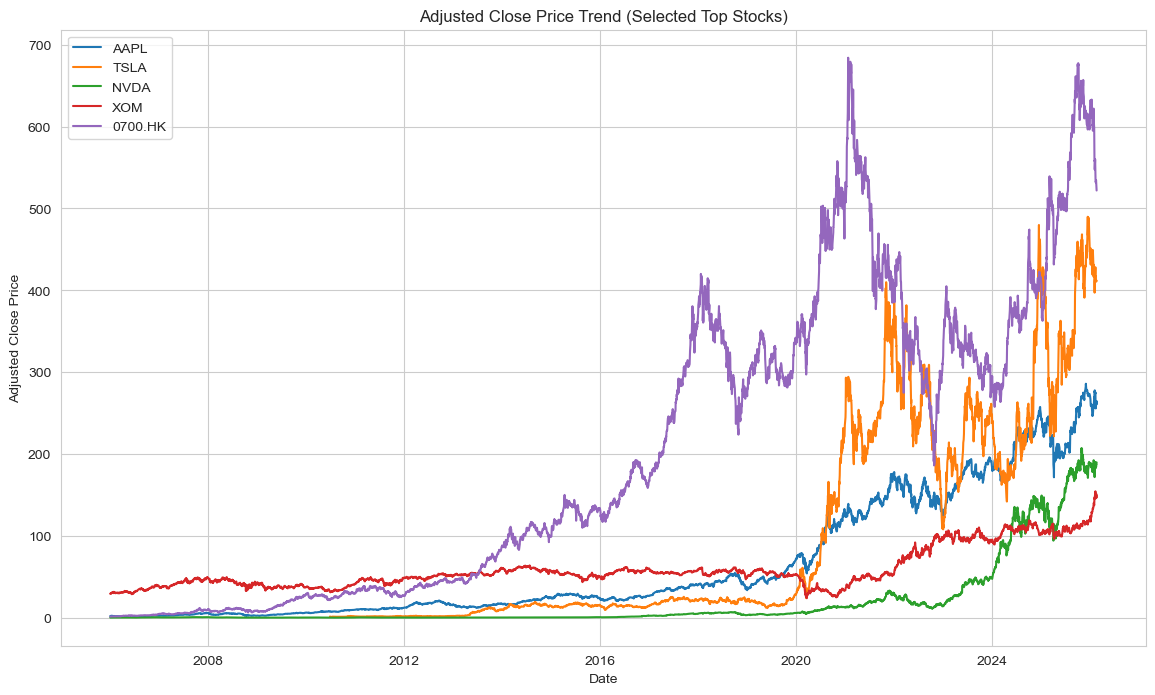

In [18]:
plt.figure(figsize=(14, 8))
for ticker in top_tickers:
    ticker_data = example_df[example_df['Ticker'] == ticker]
    plt.plot(ticker_data['Date'], ticker_data['Adj Close'], label=ticker)
plt.title('Adjusted Close Price Trend (Selected Top Stocks)')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.grid(True)
plt.show()

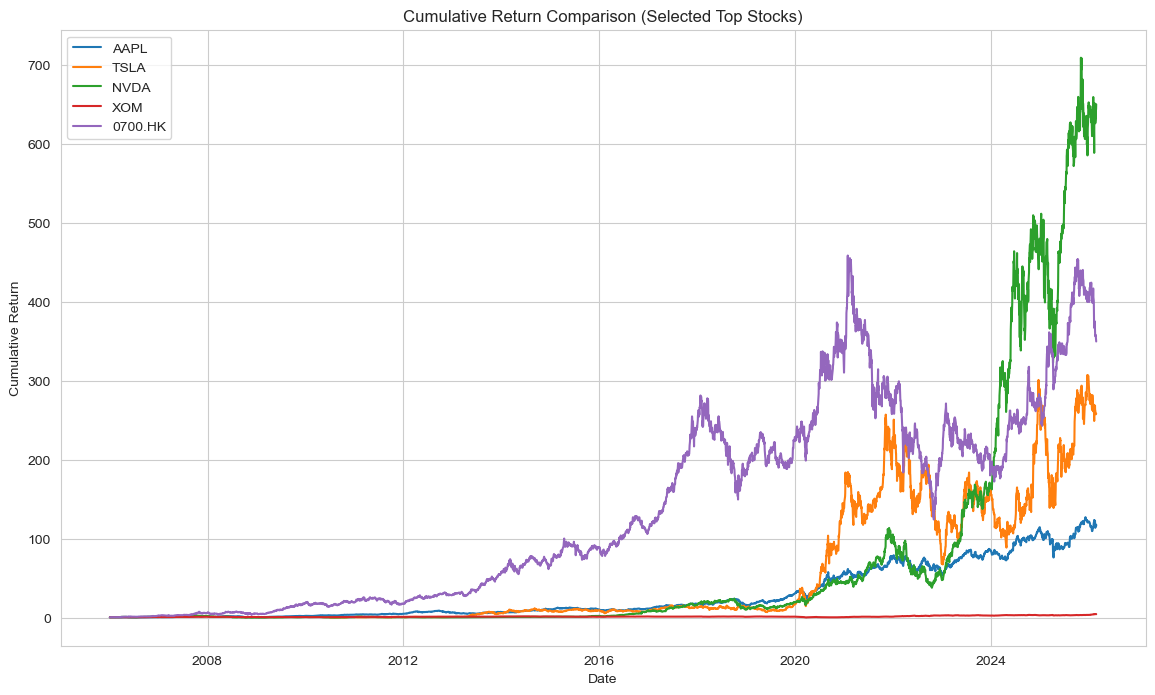

In [19]:
plt.figure(figsize=(14, 8))
for ticker in top_tickers:
    ticker_data = example_df[example_df['Ticker'] == ticker]
    plt.plot(ticker_data['Date'], ticker_data['Cumulative_Return'], label=ticker)
plt.title('Cumulative Return Comparison (Selected Top Stocks)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

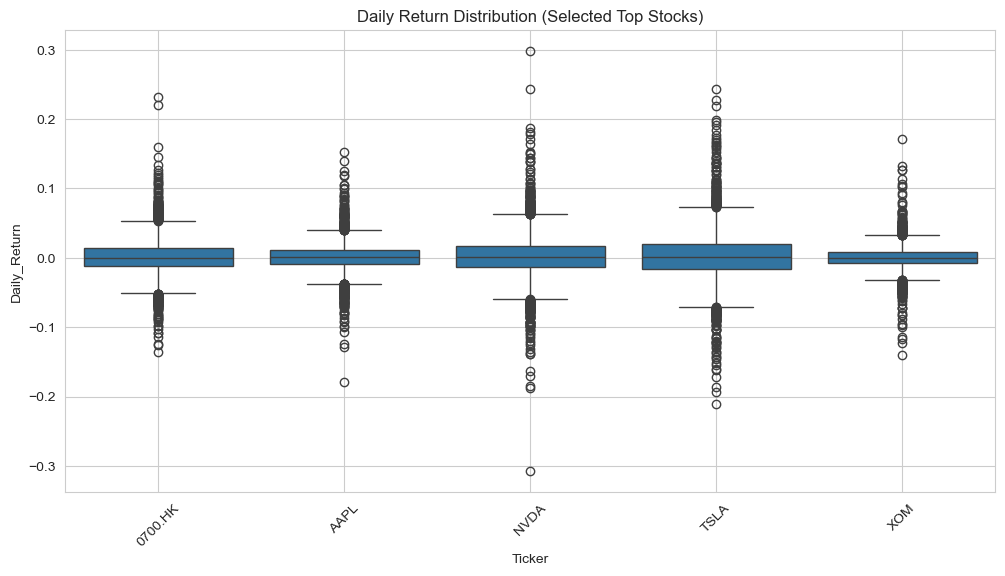

In [20]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Ticker', y='Daily_Return', data=example_df)
plt.title('Daily Return Distribution (Selected Top Stocks)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

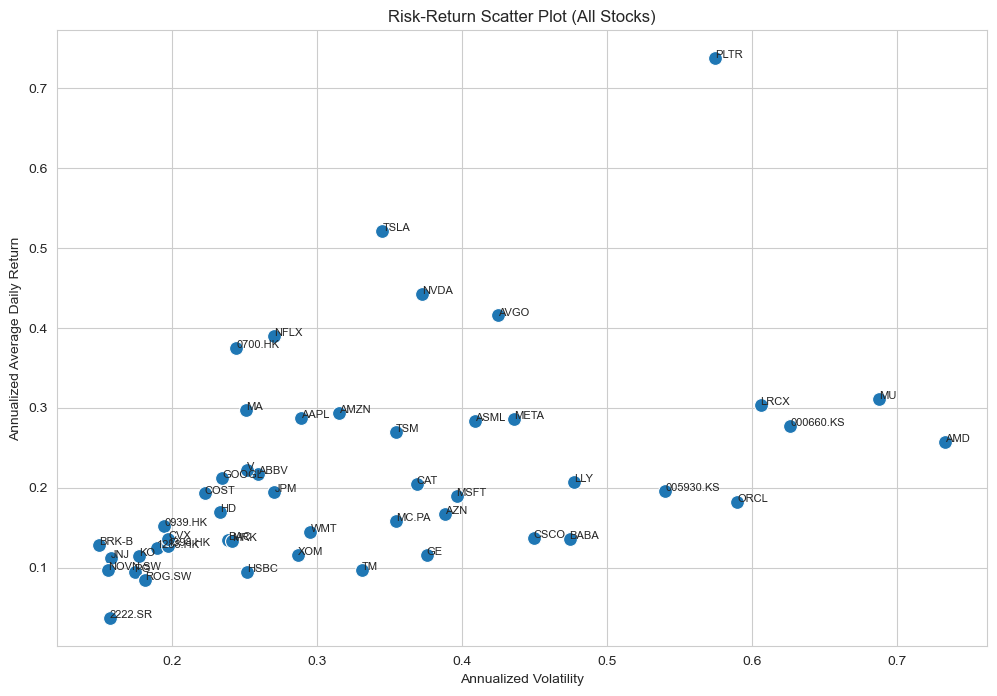

In [21]:
risk_return = df.groupby('Ticker').agg({
    'Annualized_Volatility': 'last',
    'Daily_Return': 'mean'
}).reset_index()
risk_return['Avg_Daily_Return'] = risk_return['Daily_Return'] * 252

plt.figure(figsize=(12, 8))
sns.scatterplot(data=risk_return, x='Annualized_Volatility', y='Avg_Daily_Return', s=100)
plt.title('Risk-Return Scatter Plot (All Stocks)')
plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Average Daily Return')
plt.grid(True)
for i in range(len(risk_return)):
    plt.text(risk_return['Annualized_Volatility'].iloc[i], 
             risk_return['Avg_Daily_Return'].iloc[i], 
             risk_return['Ticker'].iloc[i], fontsize=8)
plt.show()

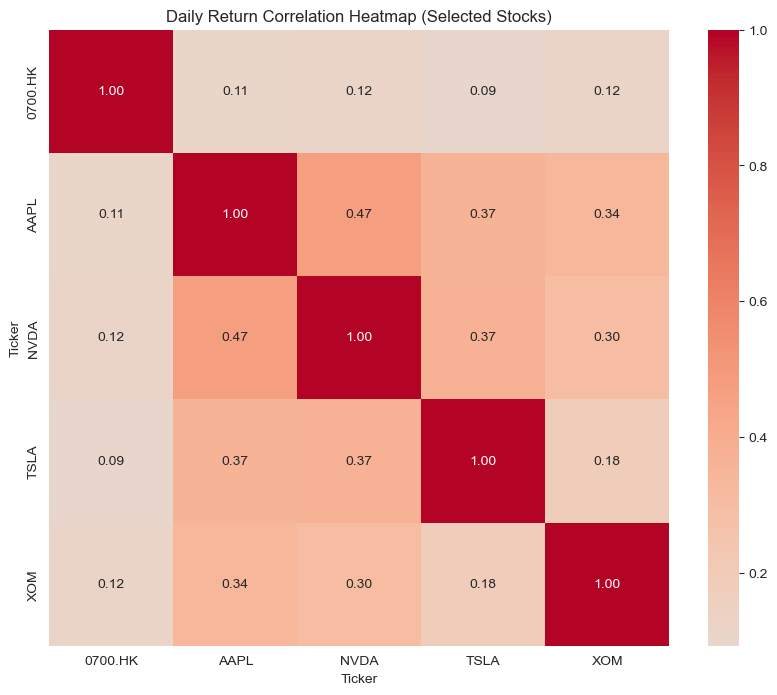

In [22]:
corr_matrix = example_df.pivot(index='Date', columns='Ticker', values='Daily_Return').corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Daily Return Correlation Heatmap (Selected Stocks)')
plt.show()

In [23]:
print("=== KEY INSIGHTS FROM ANALYSIS ===")
print("1. Top 5 stocks by Sharpe Ratio (2025 onwards):")
print(recent_summary.nlargest(5, 'Sharpe_2025')[['Sharpe_2025']])
print("\n2. Highest volatility stocks in 2025:")
print(recent_summary.nlargest(5, 'Ann_Vol_2025')[['Ann_Vol_2025']])
print("\n3. Best cumulative return performers since 2025:")
print(recent_summary.nlargest(5, 'Cum_Return_2025')[['Cum_Return_2025']])

=== KEY INSIGHTS FROM ANALYSIS ===
1. Top 5 stocks by Sharpe Ratio (2025 onwards):
           Sharpe_2025
Ticker                
000660.KS       0.4977
005930.KS       0.4977
0700.HK         0.4977
0939.HK         0.4977
1288.HK         0.4977

2. Highest volatility stocks in 2025:
           Ann_Vol_2025
Ticker                 
AMD              0.7327
MU               0.6876
000660.KS        0.6260
LRCX             0.6057
ORCL             0.5897

3. Best cumulative return performers since 2025:
         Cum_Return_2025
Ticker                  
NVDA            650.0424
0700.HK         349.9719
AVGO            291.8560
TSLA            258.5726
NFLX            211.3972


In [24]:
import os
if not os.path.exists('figures'):
    os.makedirs('figures')
print("Figures folder created")

Figures folder created


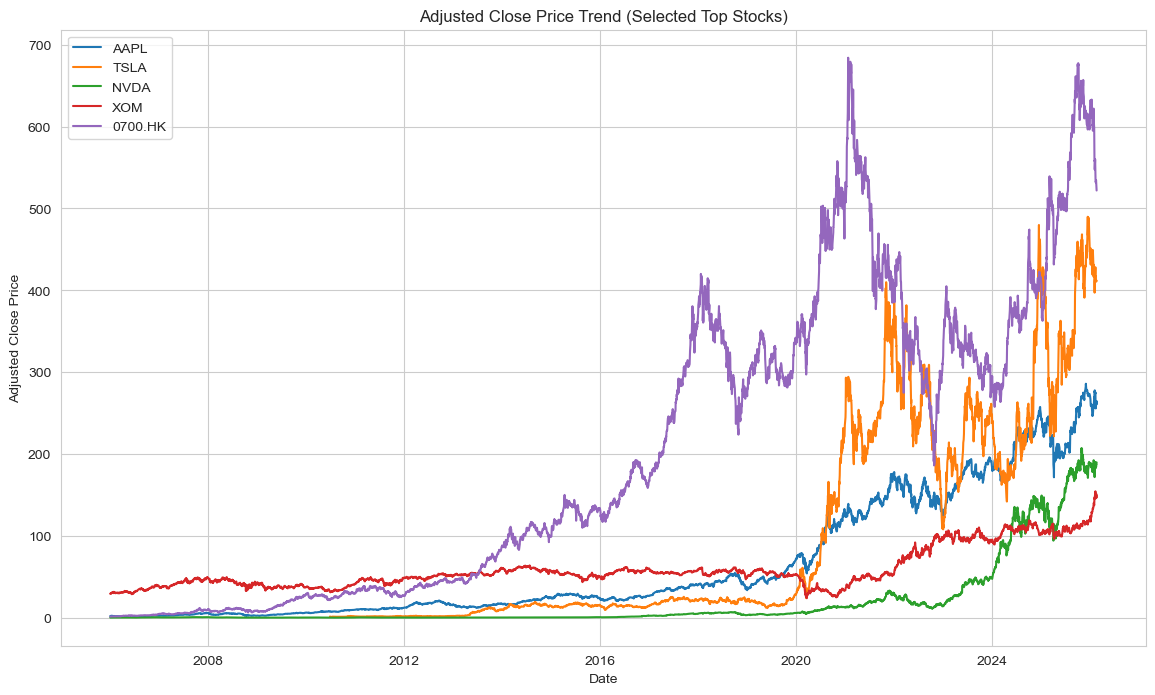

Price trend chart saved as figures/price_trend.png


In [25]:
top_tickers = ['AAPL', 'TSLA', 'NVDA', 'XOM', '0700.HK']
example_df = df[df['Ticker'].isin(top_tickers)].copy()

plt.figure(figsize=(14, 8))
for ticker in top_tickers:
    ticker_data = example_df[example_df['Ticker'] == ticker]
    plt.plot(ticker_data['Date'], ticker_data['Adj Close'], label=ticker)
plt.title('Adjusted Close Price Trend (Selected Top Stocks)')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.grid(True)
plt.savefig('figures/price_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print("Price trend chart saved as figures/price_trend.png")

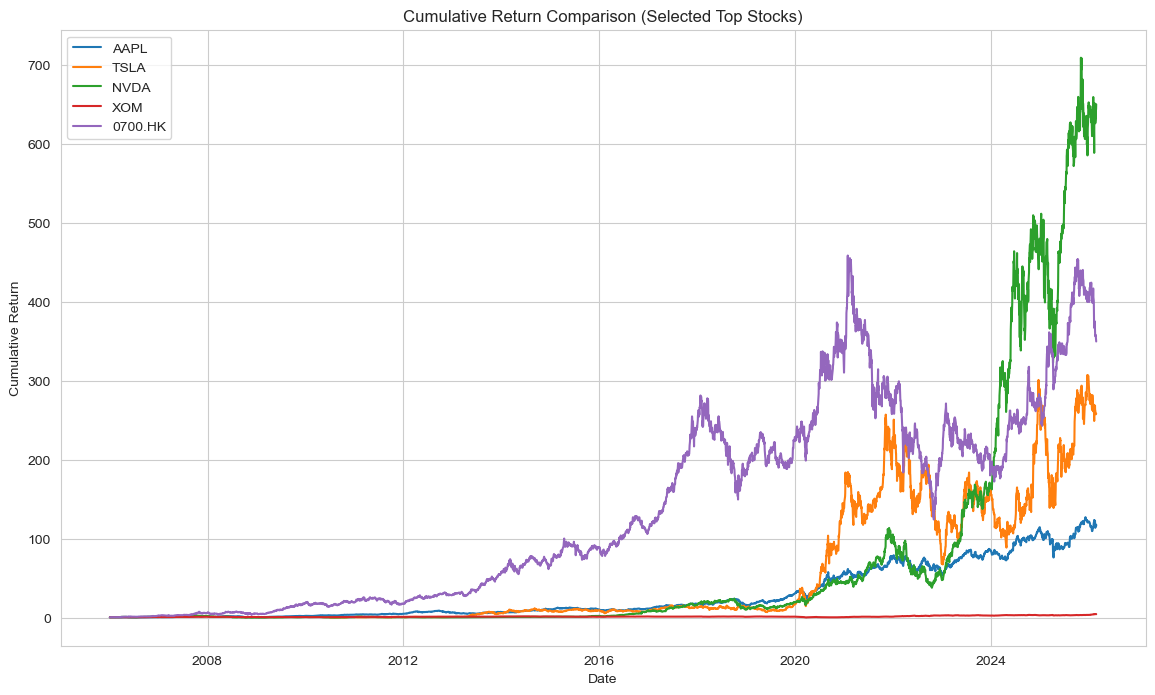

Cumulative return chart saved as figures/cumulative_return.png


In [26]:
plt.figure(figsize=(14, 8))
for ticker in top_tickers:
    ticker_data = example_df[example_df['Ticker'] == ticker]
    plt.plot(ticker_data['Date'], ticker_data['Cumulative_Return'], label=ticker)
plt.title('Cumulative Return Comparison (Selected Top Stocks)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.savefig('figures/cumulative_return.png', dpi=300, bbox_inches='tight')
plt.show()
print("Cumulative return chart saved as figures/cumulative_return.png")

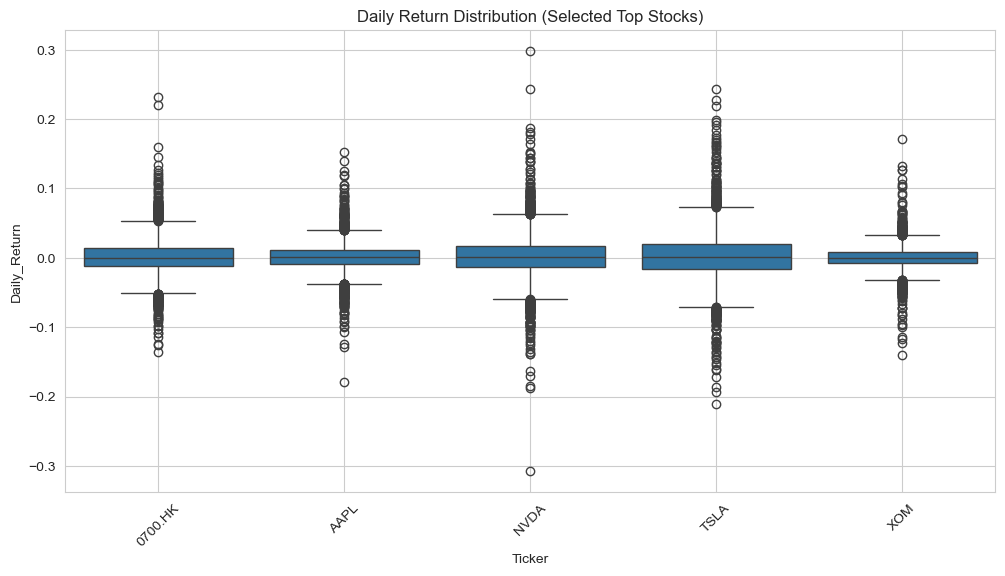

Daily return boxplot saved as figures/daily_return_boxplot.png


In [27]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Ticker', y='Daily_Return', data=example_df)
plt.title('Daily Return Distribution (Selected Top Stocks)')
plt.xticks(rotation=45)
plt.grid(True)
plt.savefig('figures/daily_return_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Daily return boxplot saved as figures/daily_return_boxplot.png")

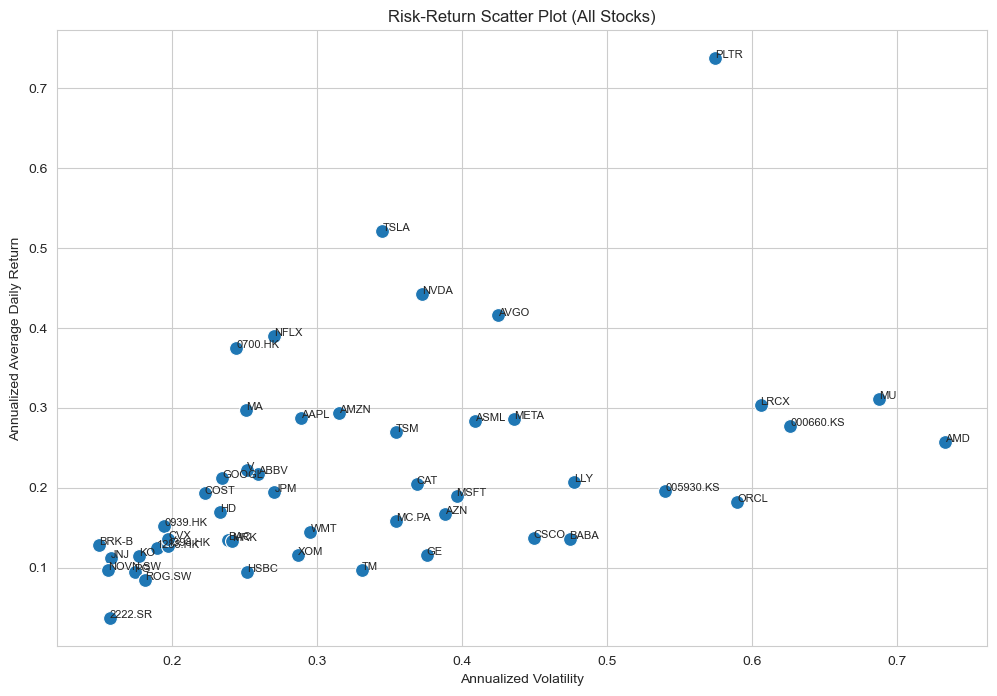

Risk-return scatter plot saved as figures/risk_return_scatter.png


In [28]:
risk_return = df.groupby('Ticker').agg({
    'Annualized_Volatility': 'last',
    'Daily_Return': 'mean'
}).reset_index()
risk_return['Avg_Daily_Return'] = risk_return['Daily_Return'] * 252

plt.figure(figsize=(12, 8))
sns.scatterplot(data=risk_return, x='Annualized_Volatility', y='Avg_Daily_Return', s=100)
plt.title('Risk-Return Scatter Plot (All Stocks)')
plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Average Daily Return')
plt.grid(True)
for i in range(len(risk_return)):
    plt.text(risk_return['Annualized_Volatility'].iloc[i], 
             risk_return['Avg_Daily_Return'].iloc[i], 
             risk_return['Ticker'].iloc[i], fontsize=8)
plt.savefig('figures/risk_return_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print("Risk-return scatter plot saved as figures/risk_return_scatter.png")

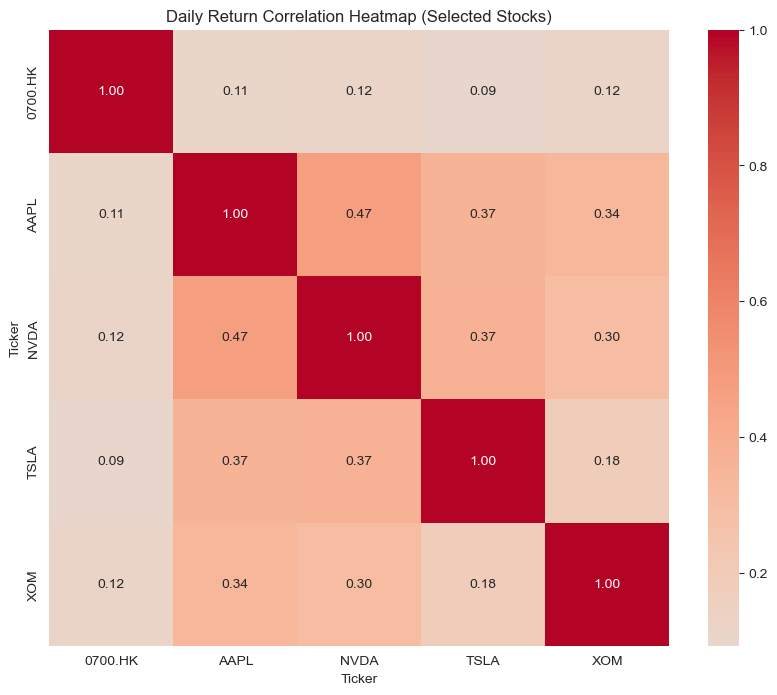

Correlation heatmap saved as figures/correlation_heatmap.png


In [29]:
corr_matrix = example_df.pivot(index='Date', columns='Ticker', values='Daily_Return').corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Daily Return Correlation Heatmap (Selected Stocks)')
plt.savefig('figures/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved as figures/correlation_heatmap.png")

In [30]:
summary.to_csv('figures/stock_summary.csv')
recent_summary.to_csv('figures/2025_summary.csv')
print("Summary tables saved as CSV files in figures folder")
print("\nAll key figures and tables are now saved and ready for Streamlit app!")

Summary tables saved as CSV files in figures folder

All key figures and tables are now saved and ready for Streamlit app!
